In [1]:
import pandas as pd
import pickle
import numpy as np


In [19]:
#bring in the historical data 
with open('pm25_total.pkl', 'rb') as f:
    pm25_historical=pickle.load(f)

In [20]:
pm25_historical.shape

(3718036, 7)

In [14]:
pm25_historical["datetime_start"] = pd.to_datetime(pm25_historical["datetime_start"], utc=True, errors="coerce")

# min and max
tmin = pm25_historical["datetime_start"].min()
tmax = pm25_historical["datetime_start"].max()

In [15]:
tmin,tmax

(Timestamp('2020-10-12 05:00:00+0000', tz='UTC'),
 Timestamp('2026-01-29 18:00:00+0000', tz='UTC'))

In [21]:
#bring in the open meteo data
with open('environmental_data.pkl','rb') as f:
    sensor_meteo_df=pickle.load(f)

In [22]:
#merge the two dataframes on sensor_id and date
sensor_meteo_df.head(3)

,time,temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,station_id,station_lat,station_lon
0,2024-12-01 00:00:00,-0.4,94,-1.2,5.0,71,1008.4,0.0,1285353,37.5644,126.935
1,2024-12-01 01:00:00,-1.9,97,-2.3,2.9,79,1008.2,0.0,1285353,37.5644,126.935
2,2024-12-01 02:00:00,-2.6,99,-2.7,4.2,83,1008.1,0.0,1285353,37.5644,126.935


In [25]:
earliest = sensor_meteo_df['time'].min()
latest=sensor_meteo_df['time'].max()

In [26]:
earliest, latest

(Timestamp('2024-12-01 00:00:00'), Timestamp('2025-08-31 23:00:00'))

In [28]:
sensor_meteo_df.head(2)

,time,temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,station_id,station_lat,station_lon
0,2024-12-01 00:00:00,-0.4,94,-1.2,5.0,71,1008.4,0.0,1285353,37.5644,126.935
1,2024-12-01 01:00:00,-1.9,97,-2.3,2.9,79,1008.2,0.0,1285353,37.5644,126.935


In [27]:
pm25_historical.head(5)

,sensor_id,location_id,location_name,datetime_start,datetime_end,value,unit
0,6566257,1285353,SPARTAN - Seoul,2020-10-12 05:00:00+00:00,2020-10-12T06:00:00Z,21.9,µg/m³
1,6566257,1285353,SPARTAN - Seoul,2020-10-12 05:00:00+00:00,2020-10-12T06:00:00Z,21.9,µg/m³
2,6566257,1285353,SPARTAN - Seoul,2020-10-12 05:00:00+00:00,2020-10-12T06:00:00Z,21.9,µg/m³
3,6566257,1285353,SPARTAN - Seoul,2020-10-12 05:00:00+00:00,2020-10-12T06:00:00Z,21.9,µg/m³
4,6566257,1285353,SPARTAN - Seoul,2020-10-12 05:00:00+00:00,2020-10-12T06:00:00Z,21.9,µg/m³


In [30]:

# Example names: replace with your actual DataFrames
pm25 = pm25_historical.copy()   # has columns: location_id, datetime_start (e.g. '2020-10-12 05:00:00+00:00')
met = sensor_meteo_df.copy()           # has columns: station_id, time (e.g. '2024-12-01 00:00:00')

# 1) Parse timestamps and make them timezone-aware UTC
pm25["datetime_start"] = pd.to_datetime(pm25["datetime_start"], utc=True, errors="coerce")
met["time"] = pd.to_datetime(met["time"], errors="coerce")

# If met.time is naive but actually UTC, localize; if it's in local tz (e.g., Asia/Seoul) localize accordingly.
# Here we assume naive times are UTC. Change "UTC" to "Asia/Seoul" if needed.
if met["time"].dt.tz is None:
    met["time"] = met["time"].dt.tz_localize("UTC")
else:
    met["time"] = met["time"].dt.tz_convert("UTC")

# 2) Floor both to the hour (use lowercase 'h')
pm25["ts_hour"] = pm25["datetime_start"].dt.floor("h")
met["ts_hour"]   = met["time"].dt.floor("h")

# 3) Optional: inspect types and ranges to sanity-check
print("pm25 datetime dtype:", pm25["datetime_start"].dtype)
print("met time dtype:", met["time"].dtype)
print("pm25 time range:", pm25["ts_hour"].min(), "→", pm25["ts_hour"].max())
print("met time range:", met["ts_hour"].min(), "→", met["ts_hour"].max())

# 4) Merge on location/station and hourly timestamp
merged = pd.merge(
    pm25,
    met,
    left_on=["location_id", "ts_hour"],
    right_on=["station_id", "ts_hour"],
    how="inner",
    suffixes=("_pm25", "_met")
)

print("Merged rows:", len(merged))


pm25 datetime dtype: datetime64[ns, UTC]
met time dtype: datetime64[us, UTC]
pm25 time range: 2020-10-12 05:00:00+00:00 → 2026-01-29 18:00:00+00:00
met time range: 2024-12-01 00:00:00+00:00 → 2025-08-31 23:00:00+00:00
Merged rows: 1490779


In [31]:
merged.head(10)

,sensor_id,location_id,location_name,datetime_start,datetime_end,value,unit,ts_hour,time,temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,station_id,station_lat,station_lon
0,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
1,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
2,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
3,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
4,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
5,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
6,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
7,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
8,8533919,2622586,홍릉로,2024-12-01 01:00:00+00:00,2024-12-01T02:00:00Z,20.0,µg/m³,2024-12-01 01:00:00+00:00,2024-12-01 01:00:00+00:00,-1.7,100,-1.7,1.4,67,1000.2,0.0,2622586,37.580167,127.044856
9,8533919,2622586,홍릉로,2024-12-01 01:00:00+00:00,2024-12-01T02:00:00Z,20.0,µg/m³,2024-12-01 01:00:00+00:00,2024-12-01 01:00:00+00:00,-1.7,100,-1.7,1.4,67,1000.2,0.0,2622586,37.580167,127.044856


In [32]:
merged.to_pickle('combined_dataframe.pkl')

In [33]:
# ensure time is datetime (and timezone-aware if needed)
merged["time"] = pd.to_datetime(merged["time"], errors="coerce", utc=True)

# drop duplicates, keeping the first occurrence
df_unique = merged.drop_duplicates(subset=["station_id", "time"], keep="first").reset_index(drop=True)


In [35]:
df_unique.head(10)

,sensor_id,location_id,location_name,datetime_start,datetime_end,value,unit,ts_hour,time,temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,station_id,station_lat,station_lon
0,8533919,2622586,홍릉로,2024-12-01 00:00:00+00:00,2024-12-01T01:00:00Z,18.0,µg/m³,2024-12-01 00:00:00+00:00,2024-12-01 00:00:00+00:00,-0.9,100,-0.9,1.8,37,1000.3,0.0,2622586,37.580167,127.044856
1,8533919,2622586,홍릉로,2024-12-01 01:00:00+00:00,2024-12-01T02:00:00Z,20.0,µg/m³,2024-12-01 01:00:00+00:00,2024-12-01 01:00:00+00:00,-1.7,100,-1.7,1.4,67,1000.2,0.0,2622586,37.580167,127.044856
2,8533919,2622586,홍릉로,2024-12-01 02:00:00+00:00,2024-12-01T03:00:00Z,16.0,µg/m³,2024-12-01 02:00:00+00:00,2024-12-01 02:00:00+00:00,-2.0,100,-2.0,1.3,82,1000.1,0.0,2622586,37.580167,127.044856
3,8533919,2622586,홍릉로,2024-12-01 03:00:00+00:00,2024-12-01T04:00:00Z,19.0,µg/m³,2024-12-01 03:00:00+00:00,2024-12-01 03:00:00+00:00,-2.1,100,-2.1,1.4,130,1000.4,0.0,2622586,37.580167,127.044856
4,8533919,2622586,홍릉로,2024-12-01 04:00:00+00:00,2024-12-01T05:00:00Z,22.0,µg/m³,2024-12-01 04:00:00+00:00,2024-12-01 04:00:00+00:00,-2.3,99,-2.4,1.4,113,1000.5,0.0,2622586,37.580167,127.044856
5,8533919,2622586,홍릉로,2024-12-01 05:00:00+00:00,2024-12-01T06:00:00Z,20.0,µg/m³,2024-12-01 05:00:00+00:00,2024-12-01 05:00:00+00:00,-2.6,99,-2.8,2.1,70,1000.3,0.0,2622586,37.580167,127.044856
6,8533919,2622586,홍릉로,2024-12-01 06:00:00+00:00,2024-12-01T07:00:00Z,23.0,µg/m³,2024-12-01 06:00:00+00:00,2024-12-01 06:00:00+00:00,-2.8,99,-3.0,3.3,81,1000.2,0.0,2622586,37.580167,127.044856
7,8533919,2622586,홍릉로,2024-12-01 07:00:00+00:00,2024-12-01T08:00:00Z,21.0,µg/m³,2024-12-01 07:00:00+00:00,2024-12-01 07:00:00+00:00,-3.2,100,-3.2,2.7,90,1000.3,0.0,2622586,37.580167,127.044856
8,8533919,2622586,홍릉로,2024-12-01 08:00:00+00:00,2024-12-01T09:00:00Z,20.0,µg/m³,2024-12-01 08:00:00+00:00,2024-12-01 08:00:00+00:00,-2.3,99,-2.5,3.1,87,1000.7,0.0,2622586,37.580167,127.044856
9,8533919,2622586,홍릉로,2024-12-01 09:00:00+00:00,2024-12-01T10:00:00Z,23.0,µg/m³,2024-12-01 09:00:00+00:00,2024-12-01 09:00:00+00:00,-0.4,97,-0.8,3.6,90,1001.1,0.0,2622586,37.580167,127.044856


In [36]:
cols_to_drop = ["datetime_start", "datetime_end", "unit","ts_hour","station_id"]
study_data = df_unique.drop(columns=cols_to_drop)



In [39]:
study_data.to_pickle('overall_study_data.pkl')

In [90]:
with open('overall_study_data.pkl', 'rb') as f:
    df=pickle.load(f)

In [91]:
df.columns

Index(['sensor_id', 'location_id', 'location_name', 'value', 'time',
       'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'wind_speed_10m', 'wind_direction_10m', 'surface_pressure',
       'precipitation', 'station_lat', 'station_lon'],
      dtype='str')

In [92]:
sensor_summary=df.groupby('sensor_id',dropna=False).agg(value_count=('value','count'),first_time=('time','min'),last_time=('time','max')).reset_index()

In [93]:
# sensors with exactly 6551 values
sensors_6551 = sensor_summary.loc[sensor_summary['value_count'] == 6551, 'sensor_id']

# subset the original data
df_full_data = df[df['sensor_id'].isin(sensors_6551)].copy()

In [97]:
# 1) remove the unwanted sensor and mark outlier values as missing for imputation
df_selected = df_full_data[df_full_data['sensor_id'] != 8542830].copy()
df_selected.loc[df_selected['value'] == 10000, 'value'] = np.nan



In [98]:
missing_pct=df_selected['value'].isna().mean()*100
missing_pct

np.float64(3.315994034968237)

In [101]:
obs_per_sensor = df_selected.groupby('sensor_id').size().reset_index(name='obs_count')
obs_per_sensor

,sensor_id,obs_count
0,8533919,6551
1,8534048,6551
2,8534251,6551
3,8534588,6551
4,8534744,6551
5,8534777,6551
6,8534874,6551
7,8534887,6551
8,8534982,6551
9,8535022,6551


In [105]:
# count sensors with any missing value rows and summarize by sensor
missing_by_sensor = (
    df_selected.groupby('sensor_id')
    .agg(
        total_count=('value', 'size'),
        missing_count=('value', lambda x: x.isna().sum()),
        first_missing_time=('time', lambda x: x[x.isna().any()].min() if x.isna().any() else pd.NaT),
        last_missing_time=('time', lambda x: x[x.isna().any()].max() if x.isna().any() else pd.NaT),
        missing_time_range_hours=('time', lambda x: (x[x.isna()].max() - x[x.isna()].min()) / pd.Timedelta(hours=1) if x.isna().any() else 0)
    )
    .reset_index()
)

missing_by_sensor['missing_pct'] = 100 * missing_by_sensor['missing_count'] / missing_by_sensor['total_count']
missing_by_sensor = missing_by_sensor[missing_by_sensor['missing_count'] > 0]

sensor_missing_count = missing_by_sensor['sensor_id'].nunique()
print(f"Sensors with missing values: {sensor_missing_count}")

missing_by_sensor = missing_by_sensor.sort_values('missing_pct', ascending=False)
missing_by_sensor.head(20)

Sensors with missing values: 26


,sensor_id,total_count,missing_count,first_missing_time,last_missing_time,missing_time_range_hours,missing_pct
13,8536181,6551,580,NaT,NaT,0,8.853610
19,8537255,6551,506,NaT,NaT,0,7.724012
0,8533919,6551,374,NaT,NaT,0,5.709052
17,8537162,6551,354,NaT,NaT,0,5.403755
22,8537450,6551,303,NaT,NaT,0,4.625248
10,8535427,6551,280,NaT,NaT,0,4.274157
11,8535634,6551,233,NaT,NaT,0,3.556709
12,8535784,6551,232,NaT,NaT,0,3.541444
4,8534744,6551,223,NaT,NaT,0,3.404060
5,8534777,6551,222,NaT,NaT,0,3.388796


In [77]:
df_selected.columns

Index(['sensor_id', 'location_id', 'location_name', 'value', 'time',
       'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'wind_speed_10m', 'wind_direction_10m', 'surface_pressure',
       'precipitation', 'station_lat', 'station_lon'],
      dtype='str')

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df_train = df_selected[df_selected['value'].notna()].copy()
df_pred = df_selected[df_selected['value'].isna()].copy()

for df_ in [df_train, df_pred]:
    df_['hour'] = df_['time'].dt.hour
    df_['dayofweek'] = df_['time'].dt.dayofweek
    df_['month'] = df_['time'].dt.month

features = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
    'wind_speed_10m', 'wind_direction_10m',
    'surface_pressure', 'precipitation',
    'hour', 'dayofweek', 'month'
]

X = df_train[features]
y = df_train['value']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)

In [115]:
y_pred_val=best_rf.predict(X_val)

In [116]:
root_mean_squared_error(y_val,y_pred_mean),root_mean_squared_error(y_val,y_pred_val)

(14.691636705629982, 5.001661991931912)

In [107]:
from sklearn.model_selection import RandomizedSearchCV

model = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 200, 400, 800],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.6, 0.8, 1.0],
    'bootstrap': [True, False]
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best RMSE (cv):", -search.best_score_)
best_rf = search.best_estimator_

Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  19.1s
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  19.2s
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  19.3s
[CV] END bootstrap=False, max_depth=20, max_features=0.6, min_samples_leaf=1, min_samples_split=8, n_estimators=100; total time=  19.6s
[CV] END bootstrap=False, max_depth=20, max_features=0.6, min_samples_leaf=1, min_samples_split=8, n_estimators=100; total time=  19.9s
[CV] END bootstrap=False, max_depth=20, max_features=0.6, min_samples_leaf=1, min_samples_split=8, n_estimators=100; total time=  20.0s
[CV] END bootstrap=False, max_depth=20, max_features=0.6, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=True, max_depth=None, max_features=0.8, min_samples_leaf=2, min_samples_split=4, n_estimators=400; total time= 1.2min
[CV] END bootstrap=True, max_depth=None, max_features=0.8, min_samples_leaf=2, min_samples_split=4, n_estimators=400; total time= 1.3min
[CV] END bootstrap=True, max_depth=None, max_features=0.8, min_samples_leaf=2, min_samples_split=4, n_estimators=400; total time= 1.3min
[CV] END bootstrap=True, max_depth=20, max_features=0.6, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=  13.7s
[CV] END bootstrap=True, max_depth=20, max_features=0.6, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=  15.3s
[CV] END bootstrap=True, max_depth=None, max_features=0.8, min_samples_leaf=4, min_samples_split=4, n_estimators=200; total time=  35.2s
[CV] END bootstrap=True, max_depth=None, max_features=0.8, min_samples_leaf=4, min_samples_split=4, n_estimators=200; total time=  35.5s
[CV] END bootstrap=True, max_depth=None, max_

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

[CV] END bootstrap=False, max_depth=40, max_features=0.8, min_samples_leaf=4, min_samples_split=6, n_estimators=400; total time= 1.8min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

[CV] END bootstrap=False, max_depth=40, max_features=0.8, min_samples_leaf=4, min_samples_split=6, n_estimators=400; total time= 1.8min
[CV] END bootstrap=False, max_depth=40, max_features=0.8, min_samples_leaf=4, min_samples_split=6, n_estimators=400; total time= 1.8min
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=2, min_samples_split=6, n_estimators=800; total time= 2.0min
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=2, min_samples_split=6, n_estimators=800; total time= 2.0min
[CV] END bootstrap=False, max_depth=10, max_features=1.0, min_samples_leaf=2, min_samples_split=6, n_estimators=800; total time= 2.0min
[CV] END bootstrap=True, max_depth=40, max_features=0.8, min_samples_leaf=2, min_samples_split=2, n_estimators=800; total time= 2.0min
[CV] END bootstrap=True, max_depth=40, max_features=0.8, min_samples_leaf=2, min_samples_split=2, n_estimators=800; total time= 2.0min
[CV] END bootstrap=True, max_depth=40, max_feature

In [89]:
check=df_selected[df_selected['value'].isna()].copy()
check.shape

(0, 14)

In [108]:

# prepare the missing rows
df_pred = df_selected[df_selected['value'].isna()].copy()

for df_ in [df_pred]:
    df_['hour'] = df_['time'].dt.hour
    df_['dayofweek'] = df_['time'].dt.dayofweek
    df_['month'] = df_['time'].dt.month

X_pred = df_pred[features]

# predict missing values
df_pred['value_imputed'] = best_rf.predict(X_pred)

# put them back into the original dataset
df_imputed = df_selected.copy()
df_imputed.loc[df_imputed['value'].isna(), 'value'] = df_pred['value_imputed'].values



In [111]:
df_imputed.shape, df_selected.shape, df_imputed['value'].isna().sum(), df_selected['value'].isna().sum()


((170326, 14), (170326, 14), np.int64(0), np.int64(5648))

In [112]:
df_imputed.to_pickle('imputed_study_data.pkl')

In [113]:
df_pred['value_imputed'].head(20)

77      21.575311
78      14.506109
361     17.455835
362     15.980708
699     29.883015
700     29.252694
860     33.776014
861     34.680781
862     37.424338
863     38.188338
864     74.271953
865     73.666269
866     97.269115
867     99.097520
868     79.533947
869     68.347315
870     72.819096
973     17.644605
974     20.408935
1130    42.549945
Name: value_imputed, dtype: float64

In [50]:
#examine predictors missingness. 

predictors = [
    'temperature_2m',
    'relative_humidity_2m',
    'dew_point_2m',
    'wind_speed_10m',
    'wind_direction_10m',
    'surface_pressure',
    'precipitation'
]

# count non-missing values per predictor per sensor
presence = (
    df_full_data2.groupby('sensor_id')[predictors]
      .apply(lambda x: x.notna().sum())
      .reset_index()
)

# add total rows per sensor and percent present
presence['total_rows'] = df_full_data2.groupby('sensor_id').size().values
for col in predictors:
    presence[f'{col}_pct'] = presence[col] / presence['total_rows'] * 100

presence

,sensor_id,temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,total_rows,temperature_2m_pct,relative_humidity_2m_pct,dew_point_2m_pct,wind_speed_10m_pct,wind_direction_10m_pct,surface_pressure_pct,precipitation_pct
0,8533919,6177,6177,6177,6177,6177,6177,6177,6177,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,8534048,6421,6421,6421,6421,6421,6421,6421,6421,100.0,100.0,100.0,100.0,100.0,100.0,100.0
2,8534251,6418,6418,6418,6418,6418,6418,6418,6418,100.0,100.0,100.0,100.0,100.0,100.0,100.0
3,8534588,6401,6401,6401,6401,6401,6401,6401,6401,100.0,100.0,100.0,100.0,100.0,100.0,100.0
4,8534744,6328,6328,6328,6328,6328,6328,6328,6328,100.0,100.0,100.0,100.0,100.0,100.0,100.0
5,8534777,6329,6329,6329,6329,6329,6329,6329,6329,100.0,100.0,100.0,100.0,100.0,100.0,100.0
6,8534874,6420,6420,6420,6420,6420,6420,6420,6420,100.0,100.0,100.0,100.0,100.0,100.0,100.0
7,8534887,6362,6362,6362,6362,6362,6362,6362,6362,100.0,100.0,100.0,100.0,100.0,100.0,100.0
8,8534982,6385,6385,6385,6385,6385,6385,6385,6385,100.0,100.0,100.0,100.0,100.0,100.0,100.0
9,8535022,6413,6413,6413,6413,6413,6413,6413,6413,100.0,100.0,100.0,100.0,100.0,100.0,100.0


In [34]:
df_full_data2['time'] = pd.to_datetime(df_full_data['time'], errors='coerce', utc=True)
df_full_data2 = df_full_data2.sort_values('time')

In [37]:
#save dataset 
df_full_data2.to_pickle('cleaned_study_data.pkl')

In [36]:
sensor = sensor_summary.loc[sensor_summary['value_count'] == 6551, 'sensor_id'].iloc[0]
df_full_data_check=df_full_data2[df_full_data2['sensor_id']==sensor]
df_full_data_check['value'].describe()

count    6177.000000
mean       17.436296
std        14.287295
min         3.000000
25%         7.000000
50%        13.000000
75%        24.000000
max       116.000000
Name: value, dtype: float64

In [31]:
df_sorted = df_full_data_check.sort_values(by='value', ascending=False)
df_sorted.head(20)

,sensor_id,location_id,location_name,value,time,temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,station_lat,station_lon
5406,8533919,2622586,홍릉로,10000.0,2025-07-15 07:00:00+00:00,21.0,83,18.0,7.6,308,979.4,0.6,37.580167,127.044856
5453,8533919,2622586,홍릉로,10000.0,2025-07-17 06:00:00+00:00,23.1,95,22.3,12.9,165,987.3,0.0,37.580167,127.044856
5394,8533919,2622586,홍릉로,10000.0,2025-07-14 19:00:00+00:00,22.6,95,21.9,6.1,337,979.4,3.4,37.580167,127.044856
5395,8533919,2622586,홍릉로,10000.0,2025-07-14 20:00:00+00:00,21.5,93,20.2,4.7,358,979.9,11.6,37.580167,127.044856
5396,8533919,2622586,홍릉로,10000.0,2025-07-14 21:00:00+00:00,21.7,93,20.5,3.5,249,980.0,3.7,37.580167,127.044856
5397,8533919,2622586,홍릉로,10000.0,2025-07-14 22:00:00+00:00,21.1,94,20.1,8.1,328,980.4,2.3,37.580167,127.044856
362,8533919,2622586,홍릉로,10000.0,2024-12-16 02:00:00+00:00,-3.2,56,-10.6,2.4,228,1006.2,0.0,37.580167,127.044856
361,8533919,2622586,홍릉로,10000.0,2024-12-16 01:00:00+00:00,-3.1,58,-10.2,2.8,255,1006.4,0.0,37.580167,127.044856
5398,8533919,2622586,홍릉로,10000.0,2025-07-14 23:00:00+00:00,21.1,92,19.8,11.5,319,980.4,0.9,37.580167,127.044856
5399,8533919,2622586,홍릉로,10000.0,2025-07-15 00:00:00+00:00,21.1,92,19.8,12.5,320,980.0,0.3,37.580167,127.044856


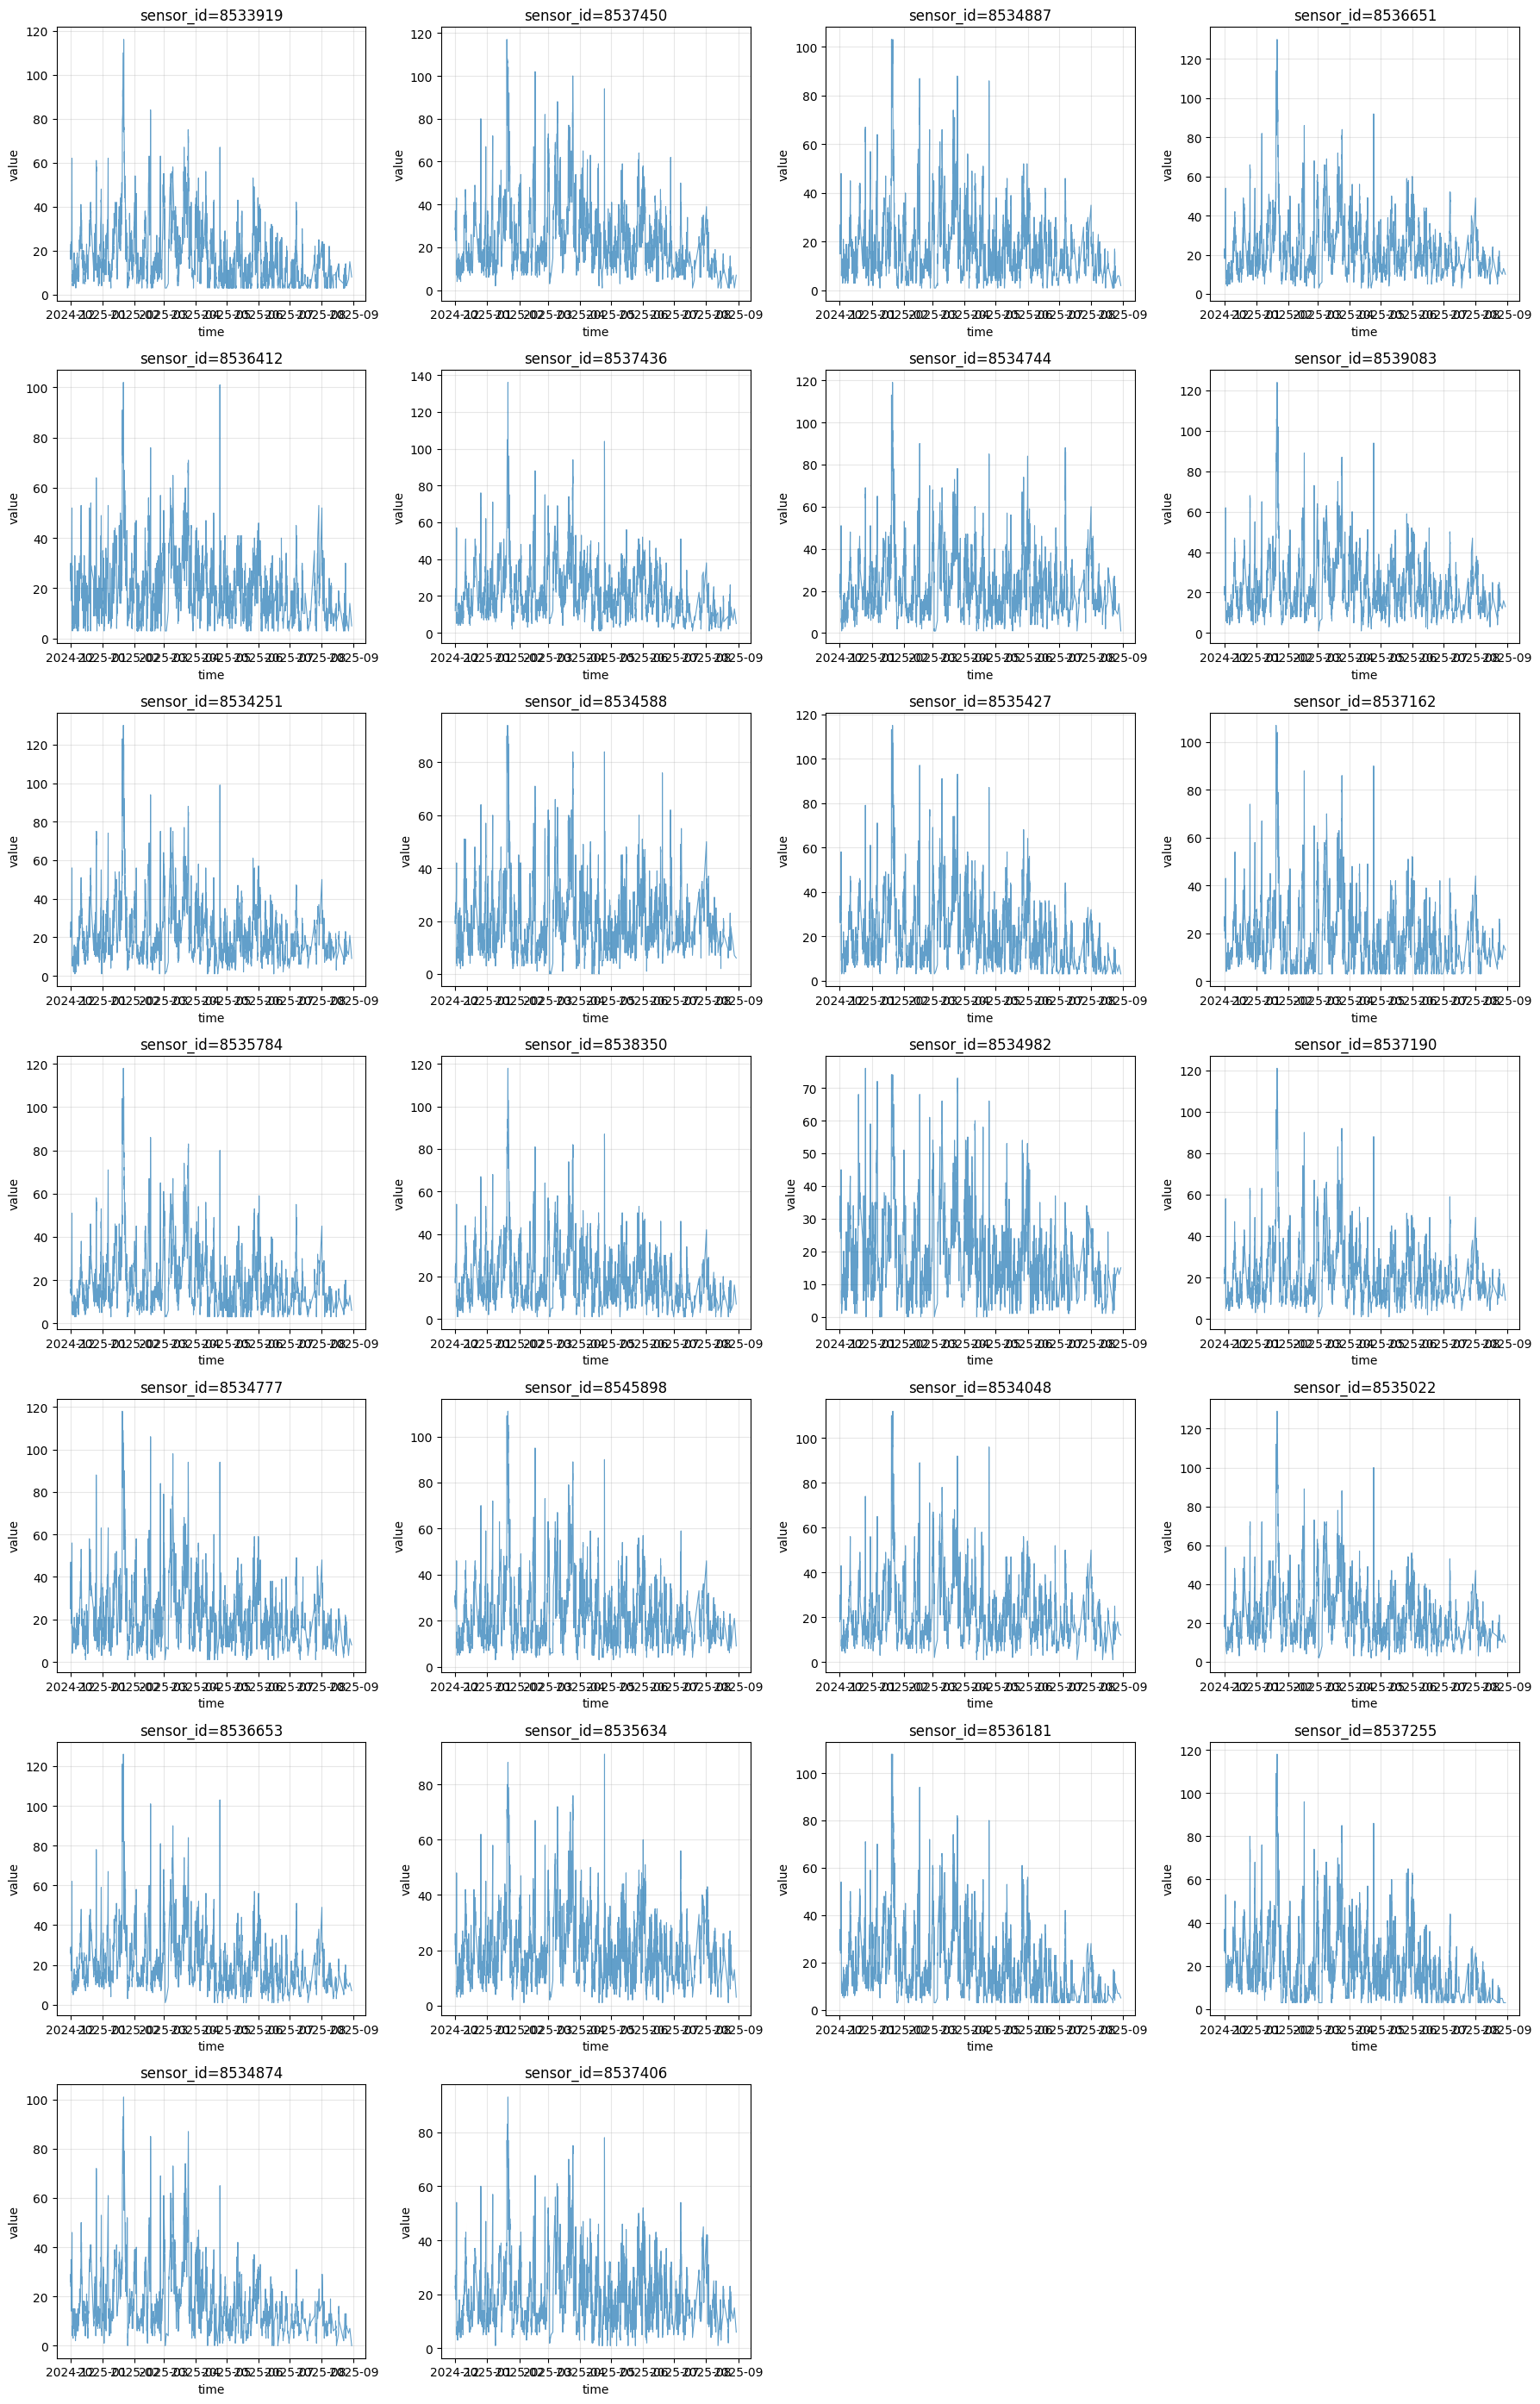

In [61]:
import matplotlib.pyplot as plt

# Get all sensors from the common dataset
sensors_common = df_common['sensor_id'].unique()

# Define grid size
n_sensors = len(sensors_common)
ncols = 4
nrows = (n_sensors + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for idx, sensor in enumerate(sensors_common):
    sensor_df = df_common[df_common['sensor_id'] == sensor].sort_values('time')
    
    axes[idx].plot(sensor_df['time'], sensor_df['value'], linewidth=0.8, alpha=0.7)
    axes[idx].set_title(f"sensor_id={sensor}")
    axes[idx].set_xlabel('time')
    axes[idx].set_ylabel('value')
    axes[idx].grid(True, alpha=0.3)

# hide unused subplots
for idx in range(n_sensors, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [45]:
check = df_full_data2[df_full_data2['sensor_id'] == 8542830].sort_values('time')

In [46]:
check

,sensor_id,location_id,location_name,value,time,temperature_2m,relative_humidity_2m,dew_point_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,station_lat,station_lon
170633,8542830,2623367,안양2동,31.0,2024-12-01 01:00:00+00:00,0.3,97,-0.1,7.3,59,1013.3,0.0,37.4051,126.9178
170634,8542830,2623367,안양2동,25.0,2024-12-01 02:00:00+00:00,0.3,99,0.1,6.0,65,1013.2,0.0,37.4051,126.9178
170635,8542830,2623367,안양2동,30.0,2024-12-01 03:00:00+00:00,0.7,99,0.5,6.6,64,1013.4,0.0,37.4051,126.9178
170636,8542830,2623367,안양2동,28.0,2024-12-01 04:00:00+00:00,0.8,99,0.6,6.7,71,1013.3,0.0,37.4051,126.9178
170637,8542830,2623367,안양2동,29.0,2024-12-01 05:00:00+00:00,0.6,99,0.5,7.6,78,1013.3,0.0,37.4051,126.9178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177177,8542830,2623367,안양2동,1.0,2025-08-31 18:00:00+00:00,28.0,77,23.6,13.1,210,1004.9,0.1,37.4051,126.9178
177178,8542830,2623367,안양2동,1.0,2025-08-31 19:00:00+00:00,26.6,85,23.9,9.8,198,1004.9,0.0,37.4051,126.9178
177179,8542830,2623367,안양2동,1.0,2025-08-31 20:00:00+00:00,25.9,89,24.0,8.5,193,1005.1,0.0,37.4051,126.9178
177180,8542830,2623367,안양2동,1.0,2025-08-31 21:00:00+00:00,25.6,91,24.1,9.4,182,1005.4,0.0,37.4051,126.9178
